In [2]:
!pip install Pinecone

In [3]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin_min
from pinecone import Pinecone
from google.colab import userdata

pc = Pinecone(api_key=userdata.get("PineconeKey"))
index = pc.Index("finance-rag")

all_ids = []
for id_batch in index.list(namespace="academic-papers"):
    all_ids.extend(id_batch)     # each batch is a list of IDs :contentReference[oaicite:3]{index=3}

print(f"Found {len(all_ids)} chunk IDs")


Found 928 chunk IDs


In [7]:
batch_size = 100
all_records = {}   # id → record dict

for i in range(0, len(all_ids), batch_size):
    batch = all_ids[i : i + batch_size]
    resp = index.fetch(
        ids=batch,
        namespace="academic-papers"
    )
    # merge this batch’s vectors into your master dict
    all_records.update(resp.vectors)

print(f"Fetched {len(all_records)} records out of {len(all_ids)} total.")

Fetched 928 records out of 928 total.


In [9]:
ids   = list(all_records.keys())
vecs  = [all_records[_id]['values'] for _id in ids]

In [11]:
X = np.vstack(vecs)   # shape = (n_chunks, embedding_dim)

# 3) cluster into K topics
K = 10
kmeans = KMeans(n_clusters=K, random_state=42).fit(X)

# 4) find the single chunk per cluster closest to its centroid
closest, _ = pairwise_distances_argmin_min(kmeans.cluster_centers_, X)
rep_ids = [ids[i] for i in closest]


print("Representative chunk IDs:", rep_ids)
print("Rep IDS length:", len(rep_ids))

Representative chunk IDs: ['4752ea92-b939-4c4a-87ed-029a739bfd6e', 'ead42f02-30ef-4c62-af74-6dfce7174b98', '497e6d4c-6e5e-4c94-b2f1-a7cd618f9294', 'cab4d6c4-b119-428e-a1f7-e9a615132fec', '94ffc23e-1f7b-4370-a0aa-a454df2d6242', '7dee1033-cb84-42dd-8897-2e2630e9fd22', '059fbc18-5a3e-4391-83e5-3bc8312882f6', '76bcef74-4fd4-4318-aef5-4d0073460a1d', '411ca021-6d59-4f14-a3cd-70d2fa6cd8c9', '271bff4f-f51f-45c1-b673-09c649d32e93']
Rep IDS length: 10


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


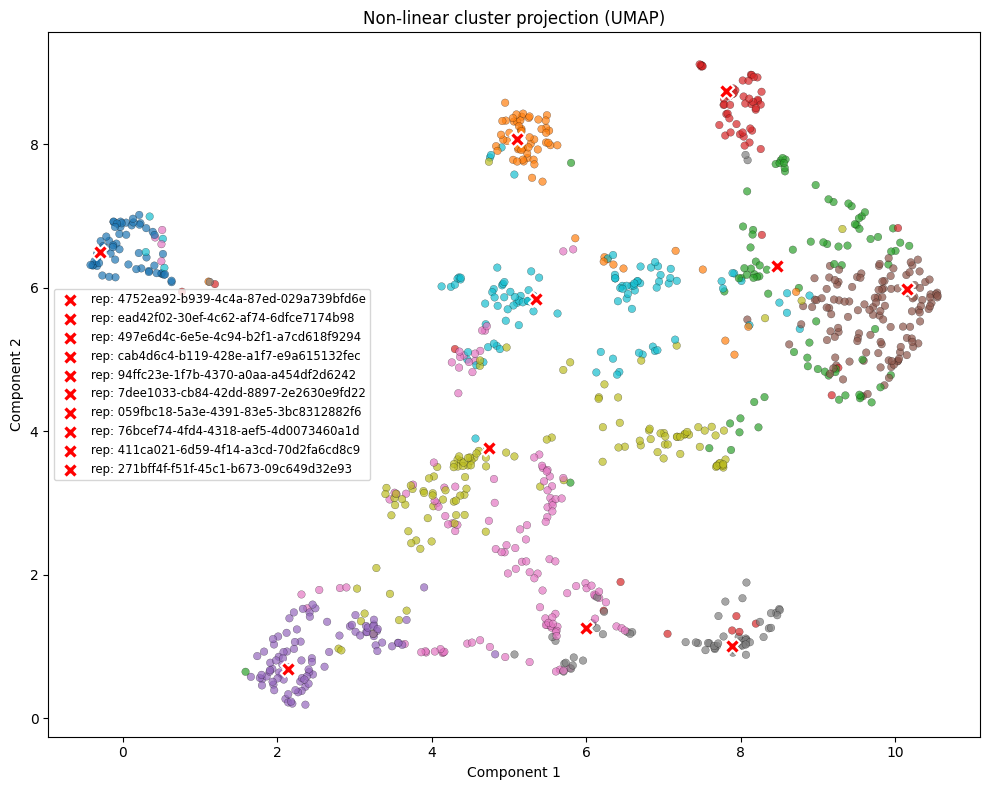

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import umap                # pip install umap-learn
from sklearn.manifold import TSNE

def visualize_clusters_nonlinear(
    X: np.ndarray,
    ids: list[str],
    rep_ids: list[str],
    kmeans,
    method: str = "umap",
    random_state: int = 42
):
    """
    Project X to 2D using a non-linear reducer (UMAP or t-SNE),
    plot points colored by cluster, and highlight the representative per cluster.

    Parameters
    ----------
    X : array, shape (n_samples, n_features)
        Your chunk embeddings.
    ids : list of str
        Chunk IDs corresponding to rows of X.
    rep_ids : list of str
        One representative ID per cluster.
    kmeans : fitted sklearn.cluster.KMeans
        The clustering you ran on X.
    method : {'umap', 'tsne'}
        Which non-linear reducer to use.
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    fig, ax : matplotlib objects
    """

    # 1) Non-linear dimensionality reduction
    if method == "umap":
        reducer = umap.UMAP(n_components=2, random_state=random_state)
    elif method == "tsne":
        reducer = TSNE(n_components=2, random_state=random_state, init="random")
    else:
        raise ValueError("method must be 'umap' or 'tsne'")

    Z = reducer.fit_transform(X)   # shape = (n_samples, 2)

    # 2) Cluster labels and rep indices
    labels = kmeans.labels_
    rep_idx = {rid: ids.index(rid) for rid in rep_ids}

    # 3) Plot
    fig, ax = plt.subplots(figsize=(10, 8))
    scatter = ax.scatter(
        Z[:, 0], Z[:, 1],
        c=labels,
        cmap="tab10",
        s=30,
        alpha=0.7,
        edgecolor="k",
        linewidth=0.2
    )
    # highlight reps
    for rid, idx in rep_idx.items():
        ax.scatter(
            Z[idx, 0], Z[idx, 1],
            marker="X", s=120,
            c="red", edgecolor="white", linewidth=1.5,
            label=f"rep: {rid}"
        )

    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.set_title(f"Non-linear cluster projection ({method.upper()})")
    # dedupe legend entries
    handles, labels_ = ax.get_legend_handles_labels()
    by_label = dict(zip(labels_, handles))
    ax.legend(by_label.values(), by_label.keys(), loc="best", fontsize="small")
    plt.tight_layout()
    plt.show()
    return fig, ax

fig_umap, ax_umap = visualize_clusters_nonlinear(X, ids, rep_ids, kmeans, method="umap")

In [21]:
# retrieve chunk texts of reps id
reps = index.fetch(ids=rep_ids, namespace="academic-papers").vectors

In [22]:
reps_text = [reps[rid].metadata['text'] for rid in rep_ids]

In [23]:
reps_text

['1904 TheJournalofFinance® SectionII,wecomputethecumulativechangeintheshareofrentsthatwould havehadtooccurinordertoexplaintheinvestmentgap,hadtheratioofintan- gible to physical capital stayed constant over the sample. In the Manufactur- ing sector, where intangible intensity is declining, the cumulative increase in rentswouldhavebeensmaller.AsimilarfindingholdsfortheServicessector, where intangible intensity is also slightly declining when using R&D capital only, as reported in Table II. In the other sectors, it would have been larger, and in some substantially so. The Healthcare sector is the most striking ex- ample; there, the increase in rents needed to account for the investment gap without a rise in intangibles would have been about 50% (or 5 p.p.) larger. In theConsumersector,thedifferenceisapproximately30%,relativetothecase where intangibles are measured including organization capital. Thus, in both of these sectors, a substantial part of the investment gap is due not purely to